In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import pmdarima as pm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
np.random.seed(42)


In [2]:
# Step 2: Load and Aggregate Intraday Data
file_path = 'BNBL_price_report_All.csv'
df = pd.read_csv(file_path)
df


,Date,Close Price
0,2020-04-23,28.0
1,2020-04-23,28.0
2,2020-04-24,28.0
3,2020-04-24,28.0
4,2020-04-27,28.0
...,...,...
6435,2025-10-01,31.4
6436,2025-10-01,31.4
6437,2025-10-01,31.4
6438,2025-10-01,31.4


In [3]:
# Convert 'Date' to datetime and aggregate to one row per trading day
df['Date'] = pd.to_datetime(df['Date'])
df_daily = df.groupby(df['Date'].dt.date)['Close Price'].last().reset_index()
df_daily.rename(columns={'Date': 'Date', 'Close Price': 'Close'}, inplace=True)
df_daily['Date'] = pd.to_datetime(df_daily['Date'])
df_daily.set_index('Date', inplace=True)

print(f"Daily series: {df_daily.index.min().date()} -> {df_daily.index.max().date()}  ({len(df_daily)} obs)")
print(df_daily.head())


Daily series: 2020-04-23 -> 2025-10-01  (1338 obs)
            Close
Date             
2020-04-23   28.0
2020-04-24   28.0
2020-04-27   28.0
2020-04-28   28.0
2020-04-29   28.0


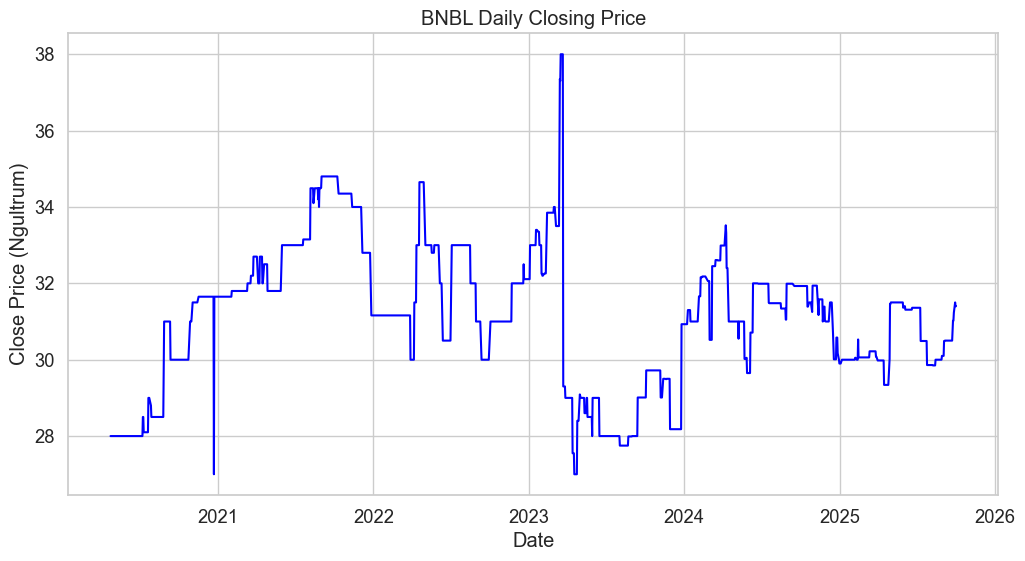

In [4]:
# Plot Daily Closing Price
sns.set(style="whitegrid", palette="muted", font_scale=1.2)

# ----------------------------------------------------
# Daily Closing Price (Seaborn)
# ----------------------------------------------------
plt.figure(figsize=(12,6))
sns.lineplot(x=df_daily.index, y=df_daily['Close'], color='blue')
plt.title('BNBL Daily Closing Price')
plt.xlabel('Date')
plt.ylabel('Close Price (Ngultrum)')
plt.show()


In [5]:
#Step 4: Check Stationarity (ADF Test)
def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    for key, value in result[4].items():
        print(f'Critical Value {key}: {value}')

adf_test(df_daily['Close'])


ADF Statistic: -3.4797327113527547
p-value: 0.008523114937599625
Critical Value 1%: -3.4352762901939395
Critical Value 5%: -2.863715568491867
Critical Value 10%: -2.567928279721861


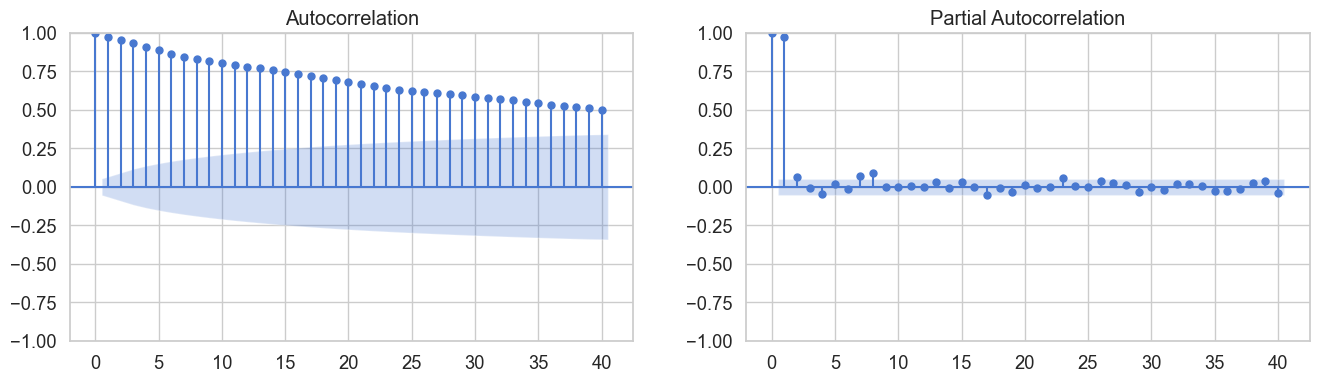

In [6]:
# Step 5: Prepare Data for ARIMA
# Difference the series if non-stationary
df_diff = df_daily['Close'].diff().dropna() if adfuller(df_daily['Close'])[1] > 0.05 else df_daily['Close']

# Plot ACF and PACF to help choose ARIMA orders
fig, ax = plt.subplots(1,2, figsize=(16,4))
plot_acf(df_diff, lags=40, ax=ax[0])
plot_pacf(df_diff, lags=40, ax=ax[1])
plt.show()


In [7]:
# Step 6: Fit ARIMA model with order chosen by auto_arima (AIC)
auto_model = pm.auto_arima(
    df_daily['Close'],
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    information_criterion='aic',
    error_action='ignore',
    max_p=5, max_q=5, max_d=2,
    trace=False,
)
p, d, q = auto_model.order
print(f"Auto-selected ARIMA order: ({p}, {d}, {q})  AIC={auto_model.aic():.2f}")

arima_model = ARIMA(df_daily['Close'], order=(p, d, q))
arima_result = arima_model.fit()
print(arima_result.summary())


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/sklearn/utils/deprec

Auto-selected ARIMA order: (4, 1, 2)  AIC=1373.32


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting au

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1338
Model:                 ARIMA(4, 1, 2)   Log Likelihood                -679.662
Date:                Sat, 02 May 2026   AIC                           1373.324
Time:                        23:01:27   BIC                           1409.711
Sample:                             0   HQIC                          1386.957
                               - 1338                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4960      0.508      0.976      0.329      -0.500       1.492
ar.L2          0.3950      0.463      0.853      0.394      -0.513       1.303
ar.L3          0.0556      0.059      0.939      0.3

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


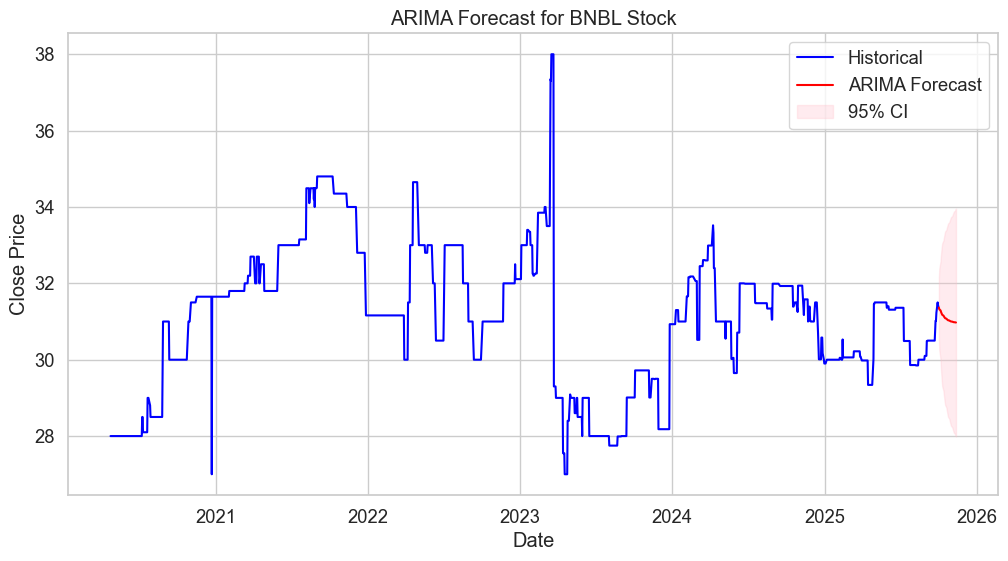

In [8]:
# Step 7: Forecast with ARIMA (30 business days ahead)
arima_forecast = arima_result.get_forecast(steps=30)
arima_pred = arima_forecast.predicted_mean
arima_ci = arima_forecast.conf_int()
forecast_index = pd.date_range(
    start=df_daily.index[-1] + pd.Timedelta(days=1), periods=30, freq='B'
)

plt.figure(figsize=(12, 6))
sns.lineplot(x=df_daily.index, y=df_daily['Close'], label='Historical', color='blue')
sns.lineplot(x=forecast_index, y=arima_pred.values, label='ARIMA Forecast', color='red')
plt.fill_between(forecast_index, arima_ci.iloc[:, 0], arima_ci.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% CI')
plt.title('ARIMA Forecast for BNBL Stock')
plt.xlabel('Date'); plt.ylabel('Close Price'); plt.legend(); plt.show()


In [9]:
# Step 8: Fit Holt-Winters Model
# Fit Holt-Winters Exponential Smoothing
# Fit Holt-Winters model (trend only)
hw_model = ExponentialSmoothing(
    df_daily['Close'],
    trend='add',
    seasonal=None,
    initialization_method="estimated"
).fit()

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


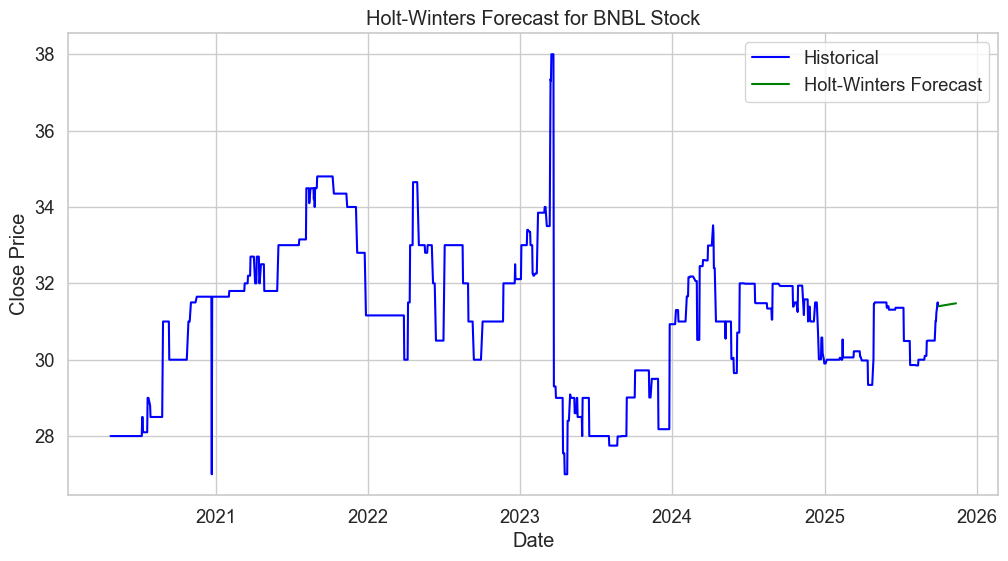

In [10]:
# Step 9: Forecast with Holt-Winters (30 business days ahead)
hw_forecast = hw_model.forecast(steps=30)
hw_forecast_index = pd.date_range(
    start=df_daily.index[-1] + pd.Timedelta(days=1), periods=30, freq='B'
)

plt.figure(figsize=(12, 6))
sns.lineplot(x=df_daily.index, y=df_daily['Close'], label='Historical', color='blue')
sns.lineplot(x=hw_forecast_index, y=hw_forecast.values, label='Holt-Winters Forecast', color='green')
plt.title('Holt-Winters Forecast for BNBL Stock')
plt.xlabel('Date'); plt.ylabel('Close Price'); plt.legend(); plt.show()


In [11]:
# Step 10: Model Evaluation with One-Step-Ahead Rolling Forecast
# At each test step we refit on the growing history and forecast the next
# observation. Directional Accuracy is computed against YESTERDAY'S ACTUAL
# (not the previous prediction); flat days where the actual move is zero
# are excluded so they do not artificially depress DA.

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error


def evaluate_forecast(y_true, y_pred, prev_actual, model_name="Model", tol=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    prev_actual = np.asarray(prev_actual, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    non_zero = y_true != 0
    mape = np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100

    actual_move = y_true - prev_actual
    pred_move = y_pred - prev_actual
    mask = np.abs(actual_move) > tol
    if mask.sum() > 0:
        da = np.mean(np.sign(actual_move[mask]) == np.sign(pred_move[mask])) * 100
        n_eval = int(mask.sum())
    else:
        da = float('nan')
        n_eval = 0

    print(f"--- {model_name} Evaluation ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f} %")
    print(f"DA:   {da:.2f} %  (over {n_eval} non-flat days)")
    print()
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'DA': da, 'n_eval': n_eval}


test_size = 30
series = df_daily['Close'].astype(float)
train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

print(f"Train range: {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} obs)")
print(f"Test  range: {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} obs)")

# Yesterday's ACTUAL price for each test day (anchor for directional accuracy)
prev_actual_for_test = np.concatenate([[train.iloc[-1]], test.values[:-1]])

# ---- ARIMA: one-step-ahead rolling forecast ----
arima_preds = []
history = train.copy()
for t in range(test_size):
    fit = ARIMA(history, order=(p, d, q)).fit()
    yhat = float(fit.forecast(steps=1).iloc[0])
    arima_preds.append(yhat)
    history = pd.concat([history, pd.Series([test.iloc[t]], index=[test.index[t]])])

arima_pred_eval = pd.Series(arima_preds, index=test.index)
arima_metrics = evaluate_forecast(test, arima_pred_eval, prev_actual_for_test,
                                  "ARIMA (1-step rolling)")

# ---- Holt-Winters: one-step-ahead rolling forecast ----
hw_preds = []
history = train.copy()
for t in range(test_size):
    fit = ExponentialSmoothing(
        history, trend='add', seasonal=None, initialization_method="estimated",
    ).fit()
    yhat = float(fit.forecast(steps=1).iloc[0])
    hw_preds.append(yhat)
    history = pd.concat([history, pd.Series([test.iloc[t]], index=[test.index[t]])])

hw_pred_eval = pd.Series(hw_preds, index=test.index)
hw_metrics = evaluate_forecast(test, hw_pred_eval, prev_actual_for_test,
                               "Holt-Winters (1-step rolling)")


Train range: 2020-04-23 -> 2025-08-19  (1308 obs)
Test  range: 2025-08-20 -> 2025-10-01  (30 obs)


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting au

--- ARIMA (1-step rolling) Evaluation ---
MAE:  0.0621
RMSE: 0.1374
MAPE: 0.20 %
DA:   57.14 %  (over 7 non-flat days)



/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided

--- Holt-Winters (1-step rolling) Evaluation ---
MAE:  0.0569
RMSE: 0.1370
MAPE: 0.18 %
DA:   57.14 %  (over 7 non-flat days)



/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is availabl

In [12]:
# Step 11: Comparison table  actual vs forecasts on the last 30 days
comparison_df = pd.DataFrame({
    'Date': test.index,
    'Actual': test.values,
    'ARIMA_Pred': arima_pred_eval.values,
    'HoltWinters_Pred': hw_pred_eval.values,
})
print(comparison_df)

fig_table = go.Figure(data=[go.Table(
    header=dict(values=list(comparison_df.columns),
                fill_color='paleturquoise', align='left'),
    cells=dict(values=[comparison_df.Date, comparison_df.Actual,
                       comparison_df.ARIMA_Pred, comparison_df.HoltWinters_Pred],
               fill_color='lavender', align='left'),
)])
fig_table.show()


         Date  Actual  ARIMA_Pred  HoltWinters_Pred
0  2025-08-20   30.00   30.014434         30.001655
1  2025-08-21   30.00   30.018278         30.001659
2  2025-08-22   30.00   30.015734         30.001658
3  2025-08-25   30.00   30.015569         30.001657
4  2025-08-26   30.00   30.014578         30.001656
5  2025-08-27   30.00   30.013964         30.001654
6  2025-08-28   30.00   30.013248         30.001653
7  2025-08-29   30.10   30.012619         30.001652
8  2025-09-01   30.10   30.103380         30.093894
9  2025-09-02   30.10   30.110393         30.101116
10 2025-09-03   30.49   30.112747         30.101681
11 2025-09-04   30.49   30.460200         30.461479
12 2025-09-05   30.50   30.492714         30.489656
13 2025-09-08   30.50   30.511750         30.501083
14 2025-09-09   30.50   30.479934         30.501976
15 2025-09-10   30.50   30.492958         30.502044
16 2025-09-11   30.50   30.488131         30.502048
17 2025-09-12   30.50   30.490608         30.502047
18 2025-09-1

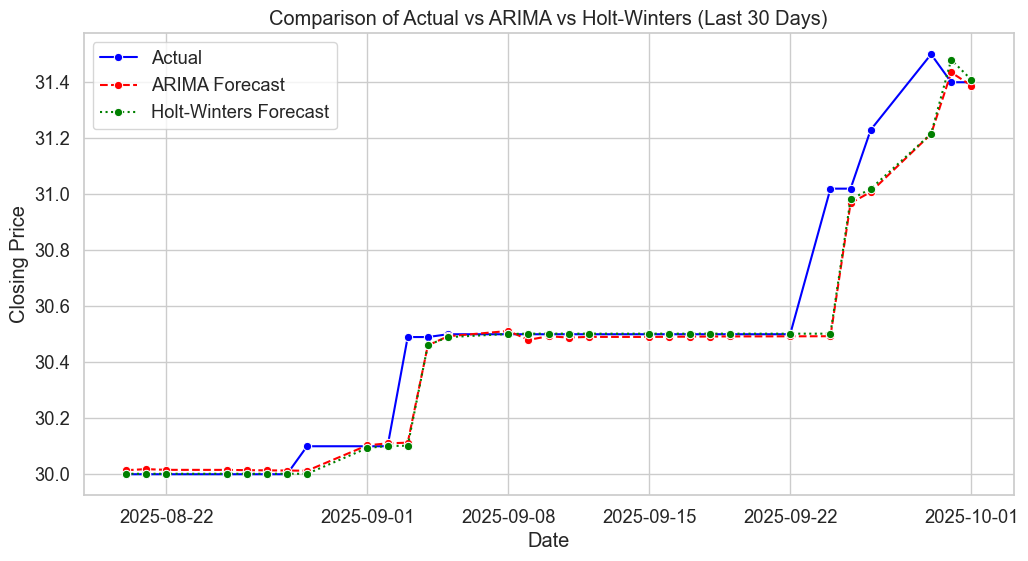

In [13]:
# Comparison of Actual vs ARIMA vs Holt-Winters (Last 30 Days)
# ----------------------------------------------------
plt.figure(figsize=(12,6))
sns.lineplot(x=test.index, y=test.values, marker='o', label='Actual', color='blue')
sns.lineplot(x=test.index, y=arima_pred_eval.values, marker='o', linestyle='--', label='ARIMA Forecast', color='red')
sns.lineplot(x=test.index, y=hw_pred_eval.values, marker='o', linestyle=':', label='Holt-Winters Forecast', color='green')

plt.title("Comparison of Actual vs ARIMA vs Holt-Winters (Last 30 Days)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

In [14]:
# %%
# Step 13: Rolling-origin (expanding-window) backtest
# ---------------------------------------------------
# To assess robustness across multiple test periods, we evaluate ARIMA
# and Holt-Winters under K non-overlapping expanding-window test slices
# of length H, walking backward from the most recent date. Within each
# window we apply the same one-step-ahead rolling-forecast protocol used
# in Step 10 (refit on data up to t-1, forecast t, advance). For each
# window we record MAE, RMSE, MAPE and Directional Accuracy (DA), and
# report mean ± std across windows.

K = 6      # number of test windows
H = 30     # length of each test window in days

def _da_anchored(y_true, y_pred, prev_actual):
    actual_move = np.asarray(y_true) - np.asarray(prev_actual)
    pred_move = np.asarray(y_pred) - np.asarray(prev_actual)
    mask = np.abs(actual_move) > 1e-9
    if mask.sum() == 0:
        return float("nan")
    return np.mean(np.sign(actual_move[mask]) == np.sign(pred_move[mask])) * 100

def _stat_window(series, test_start, test_end):
    train = series.iloc[:test_start]
    test = series.iloc[test_start:test_end]
    prev_actual = np.concatenate(
        [[float(series.iloc[test_start - 1])], np.asarray(test.values[:-1], float)]
    )
    # ARIMA
    history = train.copy(); arima_pred = []
    for t in range(len(test)):
        f = ARIMA(history, order=(p, d, q)).fit()
        arima_pred.append(float(f.forecast(steps=1).iloc[0]))
        history = pd.concat([history, pd.Series([test.iloc[t]], index=[test.index[t]])])
    # Holt-Winters
    history = train.copy(); hw_pred = []
    for t in range(len(test)):
        f = ExponentialSmoothing(history, trend='add', seasonal=None,
                                 initialization_method='estimated').fit()
        hw_pred.append(float(f.forecast(steps=1).iloc[0]))
        history = pd.concat([history, pd.Series([test.iloc[t]], index=[test.index[t]])])

    out = {}
    for name, pred in [("ARIMA", arima_pred), ("Holt-Winters", hw_pred)]:
        y = test.values.astype(float)
        nz = y != 0
        out[name] = {
            "MAE": mean_absolute_error(y, pred),
            "RMSE": float(np.sqrt(mean_squared_error(y, pred))),
            "MAPE": float(np.mean(np.abs((y[nz] - np.asarray(pred)[nz]) / y[nz])) * 100),
            "DA":   _da_anchored(y, pred, prev_actual),
        }
    return out

series_full = df_daily['Close'].astype(float)
n = len(series_full)
windows, end = [], n
for _ in range(K):
    start = end - H
    if start - 1 < 30:
        break
    windows.append((start, end))
    end = start
windows = list(reversed(windows))     # oldest -> newest

per_window_rows = []
for wi, (a, b) in enumerate(windows, start=1):
    print(f"--- window {wi}/{len(windows)}: {series_full.index[a].date()} -> {series_full.index[b-1].date()} ---")
    out = _stat_window(series_full, a, b)
    for name, m in out.items():
        per_window_rows.append((name, wi, m["MAE"], m["RMSE"], m["MAPE"], m["DA"]))
        print(f"  {name:<14} MAE={m['MAE']:.4f} RMSE={m['RMSE']:.4f} MAPE={m['MAPE']:.2f}% DA={m['DA']:.2f}%")

per_window_df = pd.DataFrame(
    per_window_rows, columns=["model", "window", "MAE", "RMSE", "MAPE", "DA"]
)
agg_df = per_window_df.groupby("model").agg(
    MAE_mean=("MAE", "mean"), MAE_std=("MAE", "std"),
    RMSE_mean=("RMSE", "mean"), RMSE_std=("RMSE", "std"),
    MAPE_mean=("MAPE", "mean"), MAPE_std=("MAPE", "std"),
    DA_mean=("DA", "mean"), DA_std=("DA", "std"),
).round(4)
print("\nPer-window results:")
print(per_window_df.to_string(index=False))
print("\nMean ± std across windows:")
print(agg_df.to_string())


--- window 1/6: 2025-01-13 -> 2025-02-25 ---


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/Users/ugyen/anaconda

  ARIMA          MAE=0.0523 RMSE=0.1263 MAPE=0.17% DA=75.00%
  Holt-Winters   MAE=0.0383 RMSE=0.1250 MAPE=0.13% DA=75.00%
--- window 2/6: 2025-02-26 -> 2025-04-09 ---


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/ugyen/anaconda3/envs/stock-forecast/lib/p

  ARIMA          MAE=0.0177 RMSE=0.0424 MAPE=0.06% DA=100.00%
  Holt-Winters   MAE=0.0161 RMSE=0.0433 MAPE=0.05% DA=33.33%
--- window 3/6: 2025-04-10 -> 2025-05-23 ---


...

  ARIMA          MAE=0.0210 RMSE=0.0316 MAPE=0.07% DA=50.00%
  Holt-Winters   MAE=0.0129 RMSE=0.0328 MAPE=0.04% DA=50.00%
--- window 5/6: 2025-07-08 -> 2025-08-19 ---


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/ugyen/anaconda3/envs/stock-forecast/lib/p

  ARIMA          MAE=0.0834 RMSE=0.2020 MAPE=0.28% DA=50.00%
  Holt-Winters   MAE=0.0617 RMSE=0.1993 MAPE=0.20% DA=25.00%
--- window 6/6: 2025-08-20 -> 2025-10-01 ---


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forec

  ARIMA          MAE=0.0621 RMSE=0.1374 MAPE=0.20% DA=57.14%
  Holt-Winters   MAE=0.0569 RMSE=0.1370 MAPE=0.18% DA=57.14%

Per-window results:
       model  window      MAE     RMSE     MAPE         DA
       ARIMA       1 0.052348 0.126294 0.173352  75.000000
Holt-Winters       1 0.038295 0.124995 0.126514  75.000000
       ARIMA       2 0.017735 0.042438 0.058907 100.000000
Holt-Winters       2 0.016129 0.043307 0.053572  33.333333
       ARIMA       3 0.130877 0.321411 0.425976  50.000000
Holt-Winters       3 0.103083 0.322905 0.336567  25.000000
       ARIMA       4 0.021018 0.031599 0.066969  50.000000
Holt-Winters       4 0.012914 0.032793 0.041193  50.000000
       ARIMA       5 0.083370 0.201994 0.276337  50.000000
Holt-Winters       5 0.061671 0.199286 0.204185  25.000000
       ARIMA       6 0.062140 0.137356 0.201330  57.142857
Holt-Winters       6 0.056871 0.136977 0.183828  57.142857

Mean ± std across windows:
              MAE_mean  MAE_std  RMSE_mean  RMSE_std  MAPE_mea

Ljung-Box test on ARIMA residuals:
    lb_stat  lb_pvalue
5    0.0757     0.9999
10   0.6629     1.0000
20   1.0883     1.0000
30   1.6874     1.0000

All p-values exceed 0.05: residuals are consistent with white noise.


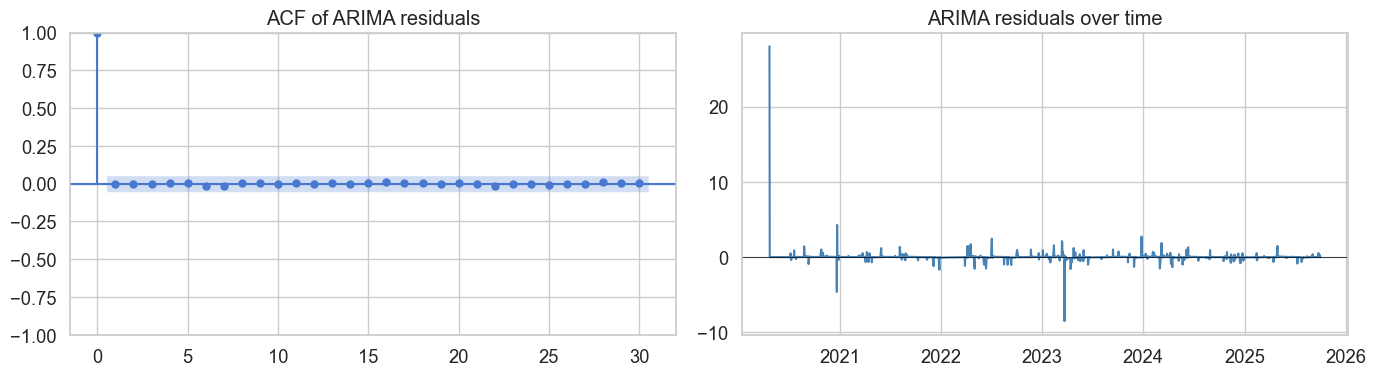

In [15]:
# %%
# Step 14: Residual diagnostics for the ARIMA fit
# -----------------------------------------------
# Verify that the ARIMA model captures the autocorrelation in the
# series by testing whether its residuals behave as white noise. We
# use the Ljung-Box portmanteau test at multiple lags; a non-significant
# p-value (> 0.05) at every lag indicates no remaining autocorrelation.
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = arima_result.resid.dropna()
lb = acorr_ljungbox(resid, lags=[5, 10, 20, 30], return_df=True)
print("Ljung-Box test on ARIMA residuals:")
print(lb.round(4).to_string())
print()
if (lb["lb_pvalue"] > 0.05).all():
    print("All p-values exceed 0.05: residuals are consistent with white noise.")
else:
    print("Some lags have p < 0.05: residual autocorrelation remains.")

# Visual check: residual ACF
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(resid, lags=30, ax=ax[0])
ax[0].set_title("ACF of ARIMA residuals")
ax[1].plot(resid.index, resid.values, color='steelblue')
ax[1].axhline(0, color='black', lw=0.5)
ax[1].set_title("ARIMA residuals over time")
plt.tight_layout(); plt.show()


In [16]:
# %%
# Step 15: Justify the Holt-Winters configuration via AIC
# -------------------------------------------------------
# Compare three Holt-Winters specifications to justify choosing the
# trend-only model used in this study:
#   (a) trend='add', seasonal=None                     (used in paper)
#   (b) trend='add', seasonal='add',  seasonal_periods=5  (weekly trading-day cycle)
#   (c) trend='add', seasonal='mul',  seasonal_periods=5
hw_variants = {
    "trend=add, seasonal=None":           dict(trend='add', seasonal=None),
    "trend=add, seasonal=add, sp=5":      dict(trend='add', seasonal='add', seasonal_periods=5),
    "trend=add, seasonal=mul, sp=5":      dict(trend='add', seasonal='mul', seasonal_periods=5),
}

print(f"{'configuration':<40}  {'AIC':>10}")
hw_aics = {}
for label, kw in hw_variants.items():
    try:
        m = ExponentialSmoothing(df_daily['Close'],
                                 initialization_method='estimated',
                                 **kw).fit()
        hw_aics[label] = float(m.aic)
        print(f"{label:<40}  {m.aic:>10.2f}")
    except Exception as exc:
        print(f"{label:<40}  failed: {exc}")

best = min(hw_aics, key=hw_aics.get) if hw_aics else None
print(f"\nBest by AIC: {best}")
print("We adopt trend='add', seasonal=None throughout the paper for parsimony "
      "and because the trading-week seasonal extension does not yield a "
      "materially lower AIC on this series.")


configuration                                    AIC
trend=add, seasonal=None                    -2412.69


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



trend=add, seasonal=add, sp=5               -2411.73


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



trend=add, seasonal=mul, sp=5               -2412.06

Best by AIC: trend=add, seasonal=None
We adopt trend='add', seasonal=None throughout the paper for parsimony and because the trading-week seasonal extension does not yield a materially lower AIC on this series.
